## **Bioinformatics Project - Computational Drug Discovery [Part 5] Comparing Regressors**

## ** Import libraries**

In [ ]:
! pip install lazypredict

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

## **Load the data set**

In [ ]:
df = pd.read_csv('bioactivitiyvv.csv')

In [ ]:
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.14
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.70
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.36
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.51
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,8.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.54
1021,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,7.64
1022,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.79
1023,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.97


In [ ]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

## **DATA PRE PROCESSING**

In [ ]:
X.shape

(1025, 881)

## Remove low variance features

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))    
X = selection.fit_transform(X)
X.shape

(1025, 173)

*Perform data splitting using 80/20 ratio*

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# ** Compare ML algorithms**

In [ ]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
models_train,predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test,predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

 93%|█████████▎| 39/42 [00:26<00:02,  1.25it/s]

[13:33:24] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


100%|██████████| 42/42 [00:26<00:00,  1.58it/s]


'tuple' object has no attribute '__name__'
Invalid Regressor(s)


 93%|█████████▎| 39/42 [00:25<00:02,  1.49it/s]

[13:33:50] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


100%|██████████| 42/42 [00:26<00:00,  1.59it/s]


In [ ]:
# Performance table of the training set (80% subset)
predictions_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
GaussianProcessRegressor,0.83,0.86,0.70,0.24
ExtraTreeRegressor,0.83,0.86,0.70,0.06
ExtraTreesRegressor,0.83,0.86,0.70,1.11
DecisionTreeRegressor,0.83,0.86,0.70,0.07
RandomForestRegressor,0.75,0.80,0.84,0.86
BaggingRegressor,0.72,0.78,0.89,0.11
MLPRegressor,0.71,0.77,0.91,1.73
HistGradientBoostingRegressor,0.69,0.75,0.94,0.55
LGBMRegressor,0.69,0.75,0.94,0.19


In [ ]:
# Performance table of the test set (20% subset)
predictions_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
NuSVR,-3.26,0.35,1.49,0.10
RandomForestRegressor,-3.36,0.34,1.50,0.84
BaggingRegressor,-3.44,0.32,1.52,0.11
SVR,-3.58,0.30,1.54,0.13
XGBRegressor,-3.59,0.30,1.54,0.30
KNeighborsRegressor,-3.63,0.30,1.55,0.02
GradientBoostingRegressor,-3.72,0.28,1.56,0.42
GammaRegressor,-3.74,0.28,1.57,0.02
TweedieRegressor,-3.76,0.28,1.57,0.04


## Data visualization of model performance

[(0.0, 1.0)]

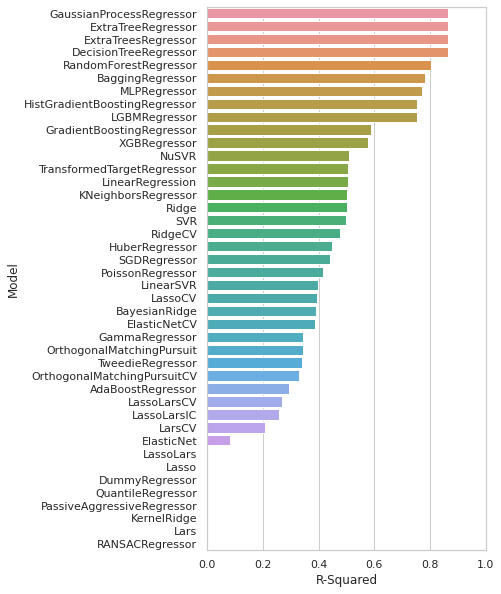

In [ ]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="R-Squared", data=predictions_train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

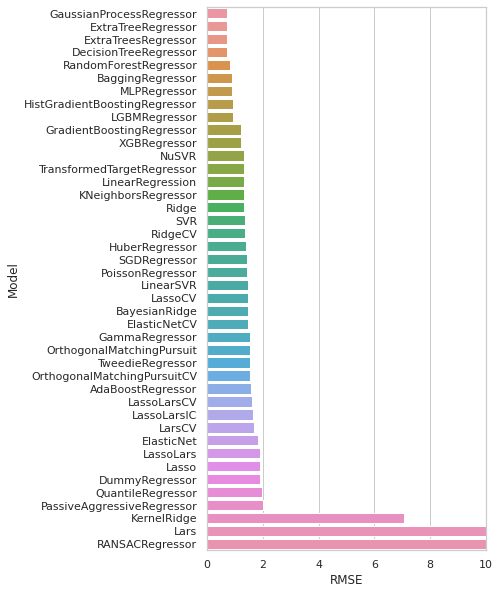

In [ ]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="RMSE", data=predictions_train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

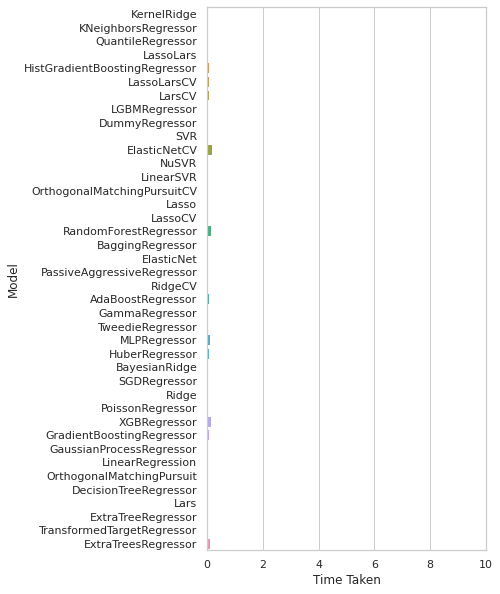

In [ ]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="Time Taken", data=predictions_train)
ax.set(xlim=(0, 10))